# Data Analysis and Model Training for the Brain Stroke Dataset

# Experimental Protocol – Brain Stroke Prediction

## Purpose of this Notebook

This notebook constitutes the experimental backbone for one dataset in a
multi-dataset comparative study on binary medical classification.

The objectives are:
1. To establish strong classical machine learning baselines.
2. To evaluate whether deep learning models provide measurable benefits
   on tabular medical data.
3. To assess model robustness, uncertainty, and statistical significance.
4. To analyze model interpretability using post-hoc explanation techniques.

The results generated here are intended to be directly reusable in a
peer-reviewed scientific publication.

## Experimental Roadmap

1. Dataset characterization and exploratory analysis  
2. Preprocessing and robustness handling  
3. Classical ML benchmarking with cross-validation  
4. Statistical significance testing  
5. Model interpretability analysis  
6. Deep learning comparison  


The *Brain Stroke Dataset* - description:

*A stroke is a medical condition in which poor blood flow to the brain causes cell death. There are two main types of stroke: ischemic, due to lack of blood flow, and hemorrhagic, due to bleeding. Both cause parts of the brain to stop functioning properly. Signs and symptoms of a stroke may include an inability to move or feel on one side of the body, problems understanding or speaking, dizziness, or loss of vision to one side. Signs and symptoms often appear soon after the stroke has occurred. If symptoms last less than one or two hours, the stroke is a transient ischemic attack (TIA), also called a mini-stroke. A hemorrhagic stroke may also be associated with a severe headache. The symptoms of a stroke can be permanent. Long-term complications may include pneumonia and loss of bladder control.*

*The main risk factor for stroke is high blood pressure. Other risk factors include high blood cholesterol, tobacco smoking, obesity, diabetes mellitus, a previous TIA, end-stage kidney disease, and atrial fibrillation. An ischemic stroke is typically caused by blockage of a blood vessel, though there are also less common causes. A hemorrhagic stroke is caused by either bleeding directly into the brain or into the space between the brain's membranes. Bleeding may occur due to a ruptured brain aneurysm. Diagnosis is typically based on a physical exam and is supported by medical imaging such as a CT scan or MRI scan. A CT scan can rule out bleeding, but may not necessarily rule out ischemia, which early on typically does not show up on a CT scan. Other tests such as an electrocardiogram (ECG) and blood tests are done to determine risk factors and rule out other possible causes. Low blood sugar may cause similar symptoms.*

*Prevention includes decreasing risk factors, surgery to open up the arteries to the brain in those with problematic carotid narrowing, and warfarin in people with atrial fibrillation. Aspirin or statins may be recommended by physicians for prevention. A stroke or TIA often requires emergency care. An ischemic stroke, if detected within three to four and half hours, may be treatable with a medication that can break down the clot. Some hemorrhagic strokes benefit from surgery. Treatment to attempt recovery of lost function is called stroke rehabilitation, and ideally takes place in a stroke unit; however, these are not available in much of the world.*

This dataset is partially preprocessed, outliers and very rare categorical values have been dropped.

First, let us install the basic libraries required for this analysis:

Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import random
import itertools
import time

from scipy.stats.mstats import winsorize
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

import shap

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


### Reproducibility

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

Next, we load the data into a pandas DataFrame `df` and inspect the first records.

Load Data

In [3]:
path = r'brain_stroke.csv'
df = pd.read_csv(path)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (4981, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


## Data Source and Citation

This experiment uses the **Brain Stroke Dataset** by Jillani SoftTech, available on Kaggle under CC BY 4.0 license.


## 1. Basic Dataset Information

This dataset contains both numerical and categorical data types. Let us examine the basic dataset metadata.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   object 
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   object 
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   object 
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 428.2+ KB


The dataset contains 4981 rows, where each row represents one individual, and 11 columns, each corresponding to a feature.

There are some missing values in the BMI column.

Below is a description of the columns:

1) gender: "Male", "Female" or "Other"

2) age: age of the patient

3) hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension

4) heart disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease 5) Ever-married: "No" or "Yes"

6) work type: "children", "Govtjov", "Never worked", "Private" or "Self-employed"

7) Residencetype: "Rural" or "Urban"

8) avg glucose level: average glucose level in blood

9) BMI: body mass index

10) smoking_status: "formerly smoked", "never smoked", "smokes" or "Unknown"*

11) stroke: 1 if the patient had a stroke or 0 if not

Note: "Unknown" in smoking_status means that the information is unavailable for this patient

The `stroke` column represents the target variable that the models will predict.

### Class Distribution

In [5]:
class_counts = df['stroke'].value_counts()
class_ratios = class_counts / len(df)

display(pd.DataFrame({
    "Count": class_counts,
    "Ratio": class_ratios
}))

,Count,Ratio
stroke,,
0,4733,0.950211
1,248,0.049789


The dataset is strongly imbalanced, with a ratio of about 95% for class 0 and 5% for class 1.
Stratified cross-validation is used to ensure each fold maintains similar class proportions.

## 2. Removal of Redundant Columns and Target Column Mapping

No unique identifiers exist, so no columns need to be dropped.

Some categorical columns contain two possible values. These can be easily mapped to integer values. Let's first identify these columns:

In [6]:
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    unique_values = df[col].unique()
    if len(unique_values) == 2:
        print(f"Column '{col}' has two unique values: {unique_values}")

Column 'gender' has two unique values: ['Male' 'Female']
Column 'ever_married' has two unique values: ['Yes' 'No']
Column 'Residence_type' has two unique values: ['Urban' 'Rural']


Let's map the binary features:

In [7]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['ever_married'] = df['ever_married'].map({'Yes': 1, 'No': 0})
df['Residence_type'] = df['Residence_type'].map({'Urban': 1, 'Rural': 0})
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1
1,1,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1
2,0,49.0,0,0,1,Private,1,171.23,34.4,smokes,1
3,0,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1
4,1,81.0,0,0,1,Private,1,186.21,29.0,formerly smoked,1


## 3. Feature Statistics

We examine descriptive statistics for all numerical features:

In [8]:
df.describe()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke
count,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000
mean,0.416382,43.419859,0.096165,0.055210,0.658502,0.508332,105.943562,28.498173,0.049789
std,0.493008,22.662755,0.294848,0.228412,0.474260,0.499981,45.075373,6.790464,0.217531
min,0.000000,0.080000,0.000000,0.000000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,77.230000,23.700000,0.000000
50%,0.000000,45.000000,0.000000,0.000000,1.000000,1.000000,91.850000,28.100000,0.000000
75%,1.000000,61.000000,0.000000,0.000000,1.000000,1.000000,113.860000,32.600000,0.000000
max,1.000000,82.000000,1.000000,1.000000,1.000000,1.000000,271.740000,48.900000,1.000000


The reported statistics include:

- count — number of non-missing values
- mean — arithmetic mean
- std — standard deviation
- min — minimum value
- 25% — first quartile
- 50% — median
- 75% — third quartile
- max — maximum value

## 4. Missing Values

We verify the presence of missing values:

In [9]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


No missing values are present in the dataset.

## 5. Duplicate Records

We check for duplicate rows:

In [10]:
df.duplicated().value_counts()

,count
False,4981


There aren't any duplicates in the dataset.

## 6. Outliers

We first analyze and then handle the outliers.

Two helper functions are defined:

- A function to compute outlier thresholds and summarize extreme values
- A function to visualize distributions using boxplots

In [11]:
def analyze_outliers(column, low=0, high=0, total=0):
    Q1 = df[column].quantile(.25)
    Q3 = df[column].quantile(.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_outliers_low = df[df[column] < lower_limit]
    df_outliers_high = df[df[column] > upper_limit]
    df_outliers_total = pd.concat([df_outliers_low, df_outliers_high])

    low_outliers_count = len(df_outliers_low)
    high_outliers_count = len(df_outliers_high)
    total_outliers_count = len(df_outliers_total)

    summary = f'''
lower quartile: {Q1}
upper quartile: {Q3}
interquartile range: {IQR}
lower limit: {lower_limit}
upper limit: {upper_limit}
number of outliers below the minimum: {low_outliers_count}
number of outliers above the maximum: {high_outliers_count}
total number of outliers: {total_outliers_count}
'''

    print(summary)

    if low > 0:
        print(f'Outliers below the minimum (number of records: {low}):\n')
        print(df_outliers_low.sort_values(by=column).head(low))

    if high > 0:
        print(f'Outliers above the maximum (number of records: {high}):\n')
        print(df_outliers_high.sort_values(by=column).head(high))

    if total > 0:
        print(f'Total outliers (number of records: {total}):\n')
        print(df_outliers_total.sort_values(by=column).head(total))

In [12]:
def show_outliers(column):
    plt.figure(figsize=(10, 1))
    sns.boxplot(data=df, x=df[column], orient="h")
    plt.grid()

The outlier analysis indicates:

**`gender`**

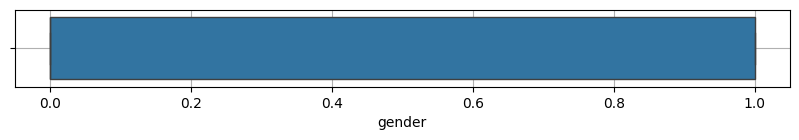

In [13]:
show_outliers('gender')

No outliers exist:

**`age`**

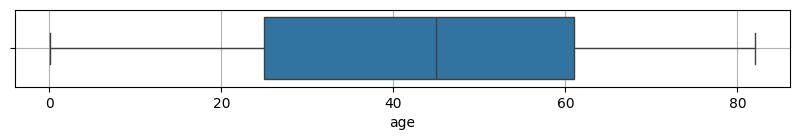

In [14]:
show_outliers('age')

No outliers exist:

**`hypertension`**

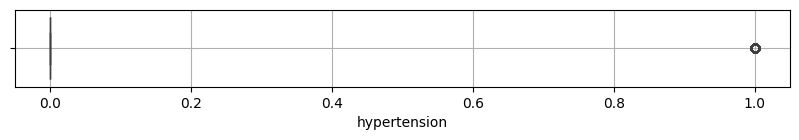

In [15]:
show_outliers('hypertension')

These are actually not outliers, the values can be 0 or 1.

**`heart_disease`**

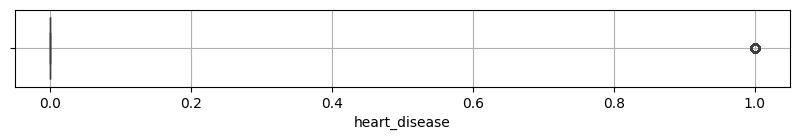

In [16]:
show_outliers('heart_disease')

These are actually not outliers, the values can be 0 or 1.

**`ever_married`**

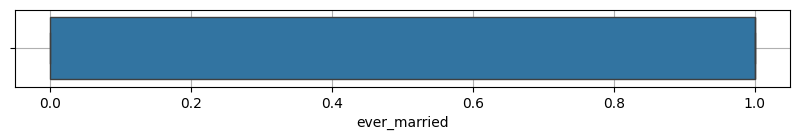

In [17]:
show_outliers('ever_married')

No outliers exist:

**`work_type`**

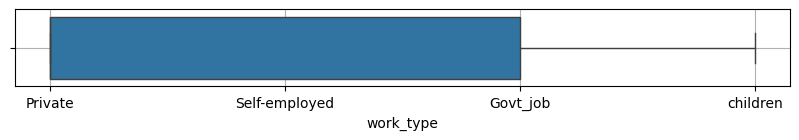

In [18]:
show_outliers('work_type')

No outliers exist.

**`Residence_type`**

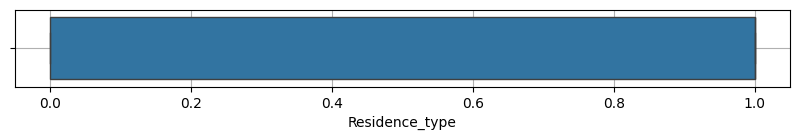

In [19]:
show_outliers('Residence_type')

No outliers exist.

**`avg_glucose_level`**

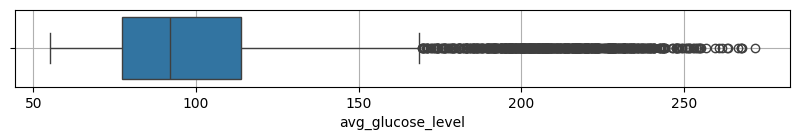

In [20]:
show_outliers('avg_glucose_level')

Several high-end outliers exist:

In [21]:
analyze_outliers('avg_glucose_level', low=5, high=5, total=0)


lower quartile: 77.23
upper quartile: 113.86
interquartile range: 36.629999999999995
lower limit: 22.28500000000001
upper limit: 168.805
number of outliers below the minimum: 0
number of outliers above the maximum: 602
total number of outliers: 602

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status, stroke]
Index: []
Outliers above the maximum (number of records: 5):

      gender   age  hypertension  heart_disease  ever_married      work_type  \
2444       1  78.0             0              1             1  Self-employed   
2000       1  28.0             0              0             1        Private   
4804       0  79.0             0              0             1        Private   
2988       1  40.0             0              0             1  Self-employed   
1318       0  57.0             0              0             1        Private  

**`bmi`**

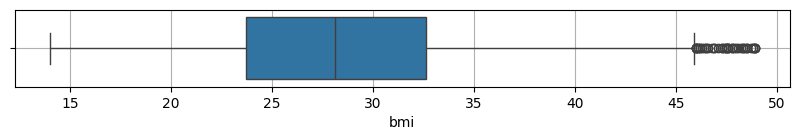

In [22]:
show_outliers('bmi')

Several high-end outliers exist:

In [23]:
analyze_outliers('bmi', low=5, high=5, total=0)


lower quartile: 23.7
upper quartile: 32.6
interquartile range: 8.900000000000002
lower limit: 10.349999999999996
upper limit: 45.95
number of outliers below the minimum: 0
number of outliers above the maximum: 43
total number of outliers: 43

Outliers below the minimum (number of records: 5):

Empty DataFrame
Columns: [gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status, stroke]
Index: []
Outliers above the maximum (number of records: 5):

      gender   age  hypertension  heart_disease  ever_married work_type  \
154        0  65.0             0              0             1   Private   
2453       0  42.0             0              0             1   Private   
3994       0  54.0             0              0             1  Govt_job   
4653       0  18.0             0              0             0   Private   
3899       0  43.0             0              0             1   Private   

      Residence_type  avg_glucose_

**`smoking_status`**

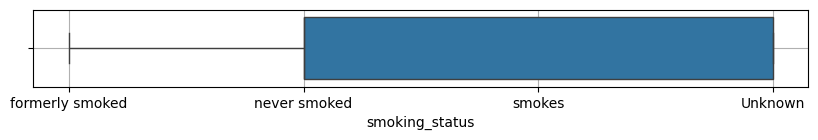

In [24]:
show_outliers('smoking_status')

These are not outliers, they're acceptable values.

### Winsorization

All data is retained as far as outliers are concerned, but we reduce the influence of extreme values by means of winsorization:

In [25]:
WIN_LIMITS = (0.01, 0.01)

def winsorize_column(col, limits=WIN_LIMITS):
    # Applies winsorization to a pandas Series (column).
    # limits: A tuple (lower_limit, upper_limit) defining the percentiles for winsorization.
    return winsorize(col, limits=limits)

# Apply winsorization only to continuous numerical columns to reduce the impact of extreme outliers
numerical_features_for_winsorization = ['age', 'avg_glucose_level', 'bmi']
for col in numerical_features_for_winsorization:
    df[col] = winsorize_column(df[col])

Winsorization identifies values below a certain lower percentile and above a certain upper percentile. It then replaces all values below the lower percentile with the value at that lower percentile, and all values above the upper percentile with the value at that upper percentile.

It's convenient because it retains all data points, preventing data loss that would occur if extreme outliers were simply removed. It reduces the undue influence of highly anomalous values (like the physiologically implausible blood pressure or height/weight readings observed during outlier analysis) on statistical analyses and machine learning models, without discarding potentially valuable information.

## 7. Data Cleaning and Preprocessing

In [26]:
# Define column types based on the cleaned df
# These are the continuous numerical features that need scaling
continuous_numerical_cols = ['age', 'avg_glucose_level', 'bmi']

# These are binary categorical features (already 0/1 encoded) that should pass through
binary_categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type']

# These are multi-value categorical features that need one-hot encoding
multi_categorical_cols = ['work_type', 'smoking_status']

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')), # For any remaining missing numerical values
            ('scaler', StandardScaler())
        ]), continuous_numerical_cols),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')), # For any remaining missing categorical values
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
        ]), multi_categorical_cols),

        # Binary columns pass through without further transformation
        ('binary', 'passthrough', binary_categorical_cols)
    ])

### Feature / target split

In [27]:
# Separate features (X) from the target variable (y)
X_raw = df.drop(columns="stroke") # Features DataFrame
y = df["stroke"] # Target Series (diabetes presence)

# Apply the preprocessor
X = pd.DataFrame(preprocessor.fit_transform(X_raw), columns=preprocessor.get_feature_names_out())

# Ensure column names are clean and consistent after one-hot encoding
# The ColumnTransformer outputs names like 'num__age', 'cat__work_type_Govt_job', 'binary__gender'
# This renames them to 'age', 'work_type_Govt_job', 'gender' for cleaner access if needed
X.columns = [col.replace('num__', '').replace('cat__', '').replace('binary__', '') for col in X.columns]

## 8. Pipelines and Hyperparameters

In [28]:
# Define a dictionary to store machine learning pipelines and their corresponding hyperparameter grids.
# Each entry consists of a pipeline object and a dictionary of hyperparameters for RandomizedSearchCV.
pipelines = {
    "Logistic Regression": (
        # Pipeline for Logistic Regression: first scales data, then applies Logistic Regression.
        Pipeline([
            ("model", LogisticRegression(
                max_iter=2000, # Maximum number of iterations for the solver to converge
                class_weight="balanced", # Adjust weights inversely proportional to class frequencies
                random_state=SEED # Seed for reproducibility
            ))
        ]),
        # Hyperparameter grid for Logistic Regression: tuning the regularization strength (C)
        {"model__C": np.logspace(-3, 3, 20)} # C is the inverse of regularization strength
    ),

    "KNN": (
        # Pipeline for K-Nearest Neighbors: scales data, then applies KNN.
        Pipeline([
            ("model", KNeighborsClassifier()) # K-Nearest Neighbors classifier
        ]),
        # Hyperparameter grid for KNN: tuning number of neighbors and weight function
        {
            "model__n_neighbors": [3, 5, 7, 9, 11], # Number of neighbors to use
            "model__weights": ["uniform", "distance"] # Weight function used in prediction
        }
    ),

    "Decision Tree": (
        # Pipeline for Decision Tree: no scaling needed as tree-based models are not sensitive to scale.
        Pipeline([
            ("model", DecisionTreeClassifier(
                class_weight="balanced",
                random_state=SEED
            ))
        ]),
        # Hyperparameter grid for Decision Tree: tuning tree depth and minimum samples for a split
        {
            "model__max_depth": [None, 5, 10, 20], # Maximum depth of the tree
            "model__min_samples_split": [2, 5, 10] # Minimum number of samples required to split an internal node
        }
    ),

    "Random Forest": (
        # Pipeline for Random Forest: no scaling needed.
        Pipeline([
            ("model", RandomForestClassifier(
                class_weight="balanced",
                random_state=SEED,
                n_jobs=-1 # Use all available CPU cores
            ))
        ]),
        # Hyperparameter grid for Random Forest: tuning number of estimators and tree depth
        {
            "model__n_estimators": [200, 400], # Number of trees in the forest
            "model__max_depth": [None, 10, 20] # Maximum depth of individual trees
        }
    ),

    "Gradient Boosting": (
        # Pipeline for Gradient Boosting: no scaling needed.
        Pipeline([
            ("model", GradientBoostingClassifier(
                random_state=42)
            ) # Gradient Boosting classifier
        ]),
        # Hyperparameter grid for Gradient Boosting: tuning number of estimators, learning rate, and tree depth
        {
            "model__n_estimators": [100, 200, 400], # Number of boosting stages
            "model__learning_rate": [0.01, 0.05, 0.1], # Step size shrinkage to prevent overfitting
            "model__max_depth": [2, 3, 4] # Maximum depth of the individual regression estimators
        }
    ),

    "Naive Bayes": (
        # Pipeline for Gaussian Naive Bayes: only the model, as it doesn't have complex hyperparameters.
        Pipeline([
            ("model", GaussianNB())
        ]),
        {} # No hyperparameters to tune for Gaussian Naive Bayes in this setup
    )
}

## 9. Nested CV Evaluation

In [29]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED) # 5-fold stratified outer cross-validation

results = {name: [] for name in pipelines} # Dictionary to store performance metrics for each model per fold
probabilities = {name: [] for name in pipelines} # Dictionary to store predicted probabilities for each model across all folds
true_labels = [] # List to store true labels across all folds

print("Starting Classical ML Nested CV Evaluation...")
# Iterate through each fold of the outer cross-validation
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"Fold {fold}")

    # Split data into training and test sets for the current fold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    true_labels.extend(y_test.values) # Collect true labels for later statistical testing

    # Iterate through each defined machine learning pipeline
    for name, (pipe, params) in pipelines.items():
        start_time = time.time() # Start time measurement
        # If hyperparameters are defined, perform Randomized Search Cross-Validation (inner loop)
        if params:
            search = RandomizedSearchCV(
                pipe, # The pipeline to optimize
                params, # The hyperparameter distribution to sample from
                n_iter=20, # Number of parameter settings that are sampled
                scoring="roc_auc", # Metric to optimize for (keeping original)
                cv=3, # 3-fold cross-validation for the inner loop
                n_jobs=-1, # Use all available CPU cores
                random_state=SEED # Seed for reproducibility
            )
            search.fit(X_train, y_train) # Fit the randomized search on the training data
            model = search.best_estimator_ # Select the best model found by RandomizedSearchCV
        else:
            # If no hyperparameters, fit the pipeline directly
            model = pipe.fit(X_train, y_train)

        end_time = time.time() # End time measurement
        train_time = end_time - start_time # Calculate training time

        # Predict probabilities on the test set
        y_prob = model.predict_proba(X_test)[:, 1] # Probability of the positive class
        y_pred = (y_prob >= 0.5).astype(int) # Convert probabilities to binary predictions (threshold 0.5)

        # Store evaluation metrics and training time for the current fold
        metrics_dict = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC_AUC": roc_auc_score(y_test, y_prob),
            "Average Precision": average_precision_score(y_test, y_prob),
            "Train Time": train_time
        }
        results[name].append(metrics_dict)

        # Store predicted probabilities for later statistical testing (Wilcoxon test)
        probabilities[name].extend(y_prob)
print("Classical ML Nested CV Evaluation Complete.")

Starting Classical ML Nested CV Evaluation...
Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Classical ML Nested CV Evaluation Complete.


## 10. Aggregated Results

In [30]:
summary = {} # Dictionary to hold mean results for each model

# Calculate the mean of performance metrics across all folds for each model
for name, fold_results in results.items():
    df_tmp = pd.DataFrame(fold_results) # Convert fold results to a DataFrame
    summary[name] = df_tmp.mean() # Calculate mean for each metric

results_df = pd.DataFrame(summary).T # Convert the summary dictionary to a DataFrame, transpose for better readability
results_df

,Accuracy,Precision,Recall,F1,ROC_AUC,Average Precision,Train Time
Logistic Regression,0.726757,0.135059,0.826612,0.232061,0.838615,0.200977,1.936662
KNN,0.949408,0.000000,0.000000,0.000000,0.705366,0.107050,1.806462
Decision Tree,0.706872,0.115979,0.722204,0.198989,0.769447,0.148203,0.590785
Random Forest,0.941778,0.129091,0.036653,0.038462,0.799632,0.148063,20.287920
Gradient Boosting,0.950211,0.200000,0.004000,0.007843,0.837289,0.180125,55.091262
Naive Bayes,0.820114,0.145694,0.540653,0.229277,0.807443,0.162649,0.003361


## 11. SHAP (trained on full data)

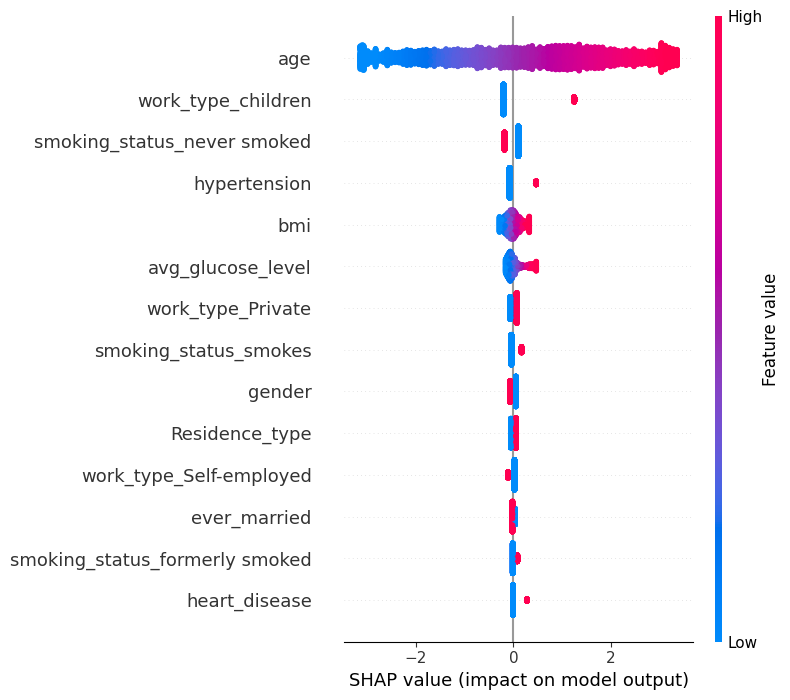

In [31]:
best_pipe, best_params = pipelines["Logistic Regression"] # Retrieve the pipeline and parameters for Logistic Regression

# Train the best model on the entire dataset (X, y) for SHAP analysis.
# .named_steps["model"] extracts the actual model object from the pipeline.
best_model = best_pipe.fit(X, y).named_steps["model"]

# Initialize a LinearExplainer for linear models like Logistic Regression
explainer = shap.LinearExplainer(best_model, X)
# Calculate SHAP values for the entire feature set X
shap_values = explainer.shap_values(X)

# Generate a summary plot of SHAP values. This plot shows feature importance
# and the impact of each feature on the model's output.
shap.summary_plot(shap_values, X)

We used Average Precision as the primary metric due to imbalance.

This SHAP summary plot visualizes the impact of each feature on the model's predictions. Here's how to interpret it:

*   **Feature Importance**: Features are ordered vertically by their importance, with the most impactful features at the top.
*   **Impact on Output**: The horizontal axis represents the SHAP value, indicating the change in the model's output prediction. Positive SHAP values push the prediction higher, and negative values push it lower.
*   **Feature Value (Color)**: The color of each dot represents the actual value of that feature for a given observation. Red indicates a high feature value, and blue indicates a low feature value.
*   **Density of Points**: The plot shows a point for each observation in the dataset. Overlapping points create a density, giving a sense of the distribution of SHAP values for that feature.

From this plot, you can see how high or low values of a feature tend to influence the prediction towards a higher probability of stroke (positive SHAP values) or lower probability of stroke (negative SHAP values). For example, if a feature like 'avg_glucose_level' shows many red dots extending to positive SHAP values, it means high values of 'avg_glucose_level' strongly contribute to a prediction of stroke.

## 12. Deep Learning Model: Multilayer Perceptron (PyTorch)

In addition to traditional machine learning models, a deep learning approach was implemented using PyTorch. The objective was to evaluate whether a neural network can outperform classical classifiers on the cardiovascular disease prediction task.

A **Multilayer Perceptron (MLP)** architecture was selected due to its suitability for tabular biomedical data.

In [32]:
def set_seed(seed=42):
    # Set seed for reproducibility across numpy and torch
    np.random.seed(seed)
    torch.manual_seed(seed)
    # Set CUDA seed for GPU operations if available
    torch.cuda.manual_seed_all(seed)
    # Ensure deterministic behavior for CUDA (can impact performance)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [33]:
class MLP(nn.Module):
    # Defines a Multilayer Perceptron (MLP) for binary classification.
    # It includes fully connected layers, ReLU activation, and Dropout regularization.
    def __init__(self, input_dim, hidden_dims=(64, 32), dropout=0.3):
        super().__init__()

        layers = []
        prev_dim = input_dim

        # Dynamically build hidden layers based on `hidden_dims`
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h)) # Fully connected layer
            layers.append(nn.ReLU()) # ReLU activation function
            layers.append(nn.Dropout(dropout)) # Dropout for regularization
            prev_dim = h

        # Output layer: maps to a single output for binary classification
        layers.append(nn.Linear(prev_dim, 1))

        # Combine all layers into a sequential network
        self.network = nn.Sequential(*layers)

    # Defines the forward pass of the network
    def forward(self, x):
        # Pass input through the network and squeeze the output to remove single-dimensional entries
        return self.network(x).squeeze(1)

In [34]:
EPOCHS = 100
LR = 1e-3
PATIENCE = 10

def train_mlp(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    patience=PATIENCE
):
    # Define the loss function (Binary Cross-Entropy with Logits for numerical stability)
    criterion = nn.BCEWithLogitsLoss()
    # Define the optimizer (Adam is a popular choice for deep learning)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_auc = -np.inf # Initialize best validation AUC score
    patience_counter = 0 # Counter for early stopping patience

    start_train_time = time.time() # Start time measurement for training

    # Training loop
    for epoch in range(epochs):
        model.train() # Set model to training mode
        for xb, yb in train_loader:
            optimizer.zero_grad() # Zero the gradients before backpropagation
            logits = model(xb) # Forward pass
            loss = criterion(logits, yb) # Compute loss
            loss.backward() # Backpropagate gradients
            optimizer.step() # Update model parameters

        # Validation phase
        model.eval() # Set model to evaluation mode
        y_true, y_prob = [], []

        with torch.no_grad(): # Disable gradient calculation during validation
            for xb, yb in val_loader:
                logits = model(xb)
                probs = torch.sigmoid(logits) # Convert logits to probabilities
                y_true.extend(yb.cpu().numpy())
                y_prob.extend(probs.cpu().numpy())

        val_auc = roc_auc_score(y_true, y_prob) # Compute ROC AUC on validation set

        # Early stopping logic
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = model.state_dict() # Save the best model state
            patience_counter = 0 # Reset patience counter
        else:
            patience_counter += 1 # Increment patience counter

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break # Stop training if patience runs out

    end_train_time = time.time() # End time measurement for training
    total_train_time = end_train_time - start_train_time

    model.load_state_dict(best_state) # Load the best model state found during training
    return model, total_train_time


In [35]:
param_grid_mlp = {
    'hidden_dims': [(64, 32), (128, 64), (128, 64, 32)],
    'dropout': [0.2, 0.3, 0.4],
    'lr': [1e-4, 1e-3, 1e-2],
    'batch_size': [32, 64, 128]
}

MLP_RANDOM_SEARCH_ITERATIONS = 20 # Number of random hyperparameter combinations to try

mlp_results = [] # List to store evaluation metrics for each fold
mlp_probabilities = [] # List to store predicted probabilities for all folds

# Initialize StratifiedKFold for consistent cross-validation splits
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Starting MLP Nested CV Evaluation...")
# Iterate through each fold of the outer cross-validation
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"MLP – Fold {fold}")

    # Split data into training and test sets for the current fold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Data Scaling: Apply StandardScaler to training and test data
    # Scaler is fitted only on the training data to prevent data leakage
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Inner validation split: Create a validation set from the training data
    val_split = int(0.8 * len(X_train_scaled))

    X_tr, X_val = X_train_scaled[:val_split], X_train_scaled[val_split:]
    y_tr, y_val = y_train.values[:val_split], y_train.values[val_split:]

    # Convert numpy arrays to PyTorch tensors for model input
    # Datasets for inner loop, batch_size will be set dynamically
    train_ds_inner = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32)
    )

    val_ds_inner = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32)
    )

    # Initialize best validation AUC and corresponding hyperparameters for this fold
    best_val_auc_mlp_fold = -np.inf
    best_params_mlp_fold = {}

    # Perform random search for hyperparameters
    for i in range(MLP_RANDOM_SEARCH_ITERATIONS):
        set_seed(SEED + i) # Reset seed for reproducibility of random choices within each iteration

        # Sample hyperparameters
        current_hidden_dims = random.choice(param_grid_mlp['hidden_dims'])
        current_dropout = random.choice(param_grid_mlp['dropout'])
        current_lr = random.choice(param_grid_mlp['lr'])
        current_batch_size = random.choice(param_grid_mlp['batch_size'])

        # Create DataLoaders with sampled batch_size
        train_loader_inner = DataLoader(train_ds_inner, batch_size=current_batch_size, shuffle=True)
        val_loader_inner = DataLoader(val_ds_inner, batch_size=256) # Keep val batch size consistent for evaluation

        # Instantiate MLP model with sampled hyperparameters
        current_model = MLP(input_dim=X.shape[1], hidden_dims=current_hidden_dims, dropout=current_dropout)

        # Train the model
        trained_model, _ = train_mlp(current_model, train_loader_inner, val_loader_inner, lr=current_lr)

        # Evaluate on validation set
        trained_model.eval() # Set model to evaluation mode
        y_true_val, y_prob_val = [], []
        with torch.no_grad():
            for xb_val, yb_val in val_loader_inner:
                logits_val = trained_model(xb_val)
                probs_val = torch.sigmoid(logits_val)
                y_true_val.extend(yb_val.cpu().numpy())
                y_prob_val.extend(probs_val.cpu().numpy())
        current_val_auc = roc_auc_score(y_true_val, y_prob_val)

        # Update best hyperparameters if current model is better
        if current_val_auc > best_val_auc_mlp_fold:
            best_val_auc_mlp_fold = current_val_auc
            best_params_mlp_fold = {
                'hidden_dims': current_hidden_dims,
                'dropout': current_dropout,
                'lr': current_lr,
                'batch_size': current_batch_size
            }
            # print(f"  New best: AUC={current_val_auc:.4f}, Params={best_params_mlp_fold}")

    print(f"  Best params for Fold {fold}: {best_params_mlp_fold}")

    # Train final MLP model for this fold using the best hyperparameters found
    final_mlp_model = MLP(
        input_dim=X.shape[1],
        hidden_dims=best_params_mlp_fold['hidden_dims'],
        dropout=best_params_mlp_fold['dropout']
    )

    # Prepare DataLoaders for final training with best batch_size
    train_loader_final = DataLoader(train_ds_inner, batch_size=best_params_mlp_fold['batch_size'], shuffle=True)
    val_loader_final = DataLoader(val_ds_inner, batch_size=256) # Val loader can use larger batch size

    # Retrain the final model with best hyperparameters
    final_trained_model, mlp_train_time = train_mlp(final_mlp_model, train_loader_final, val_loader_final, lr=best_params_mlp_fold['lr'])

    # Test DataLoaders using the true test set and its labels
    test_ds = TensorDataset(
        torch.tensor(X_test_scaled, dtype=torch.float32),
        torch.tensor(y_test.values, dtype=torch.float32)
    )
    test_loader = DataLoader(test_ds, batch_size=256)

    # Evaluation phase: Make predictions on the test set
    final_trained_model.eval() # Set model to evaluation mode
    y_prob = []
    with torch.no_grad(): # Disable gradient calculation
        for xb, _ in test_loader:
            probs = torch.sigmoid(final_trained_model(xb)) # Get probabilities from logits
            y_prob.extend(probs.cpu().numpy())

    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int) # Convert probabilities to binary predictions

    # Store evaluation metrics for the current fold
    mlp_results.append({
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Average Precision": average_precision_score(y_test, y_prob),
        "Train Time": mlp_train_time # Add training time here
    })

    # Store predicted probabilities for the Wilcoxon test
    mlp_probabilities.extend(y_prob)
print("MLP Nested CV Evaluation Complete.")


Starting MLP Nested CV Evaluation...
MLP – Fold 1
Early stopping at epoch 83
Early stopping at epoch 18
Early stopping at epoch 14
Early stopping at epoch 19
Early stopping at epoch 12
Early stopping at epoch 14
Early stopping at epoch 25
Early stopping at epoch 16
Early stopping at epoch 34
Early stopping at epoch 89
Early stopping at epoch 19
Early stopping at epoch 15
Early stopping at epoch 45
Early stopping at epoch 11
Early stopping at epoch 16
Early stopping at epoch 19
Early stopping at epoch 12
  Best params for Fold 1: {'hidden_dims': (64, 32), 'dropout': 0.2, 'lr': 0.0001, 'batch_size': 32}
Early stopping at epoch 95
MLP – Fold 2
Early stopping at epoch 39
Early stopping at epoch 13
Early stopping at epoch 24
Early stopping at epoch 17
Early stopping at epoch 26
Early stopping at epoch 11
Early stopping at epoch 16
Early stopping at epoch 33
Early stopping at epoch 14
Early stopping at epoch 22
Early stopping at epoch 53
Early stopping at epoch 25
Early stopping at epoch 19


In [36]:
# Original code to collect all fold results into df_results
all_results_list = []

# Iterate through classical model results
for model_name, fold_results in results.items():
    for fold_num, metrics in enumerate(fold_results, 1):
        fold_entry = {
            "model_name": model_name,
            "fold": fold_num
        }
        fold_entry.update(metrics)
        all_results_list.append(fold_entry)

# Iterate through MLP (PyTorch) results
for fold_num, metrics in enumerate(mlp_results, 1):
    fold_entry = {
        "model_name": "MLP (PyTorch)",
        "fold": fold_num
    }
    fold_entry.update(metrics)
    all_results_list.append(fold_entry)

df_results = pd.DataFrame(all_results_list)

print(df_results)


             model_name  fold  Accuracy  Precision    Recall        F1  \
0   Logistic Regression     1  0.752257   0.149466  0.840000  0.253776   
1   Logistic Regression     2  0.743976   0.147766  0.860000  0.252199   
2   Logistic Regression     3  0.714859   0.125000  0.780000  0.215470   
3   Logistic Regression     4  0.706827   0.132931  0.897959  0.231579   
4   Logistic Regression     5  0.715863   0.120130  0.755102  0.207283   
5                   KNN     1  0.949850   0.000000  0.000000  0.000000   
6                   KNN     2  0.949799   0.000000  0.000000  0.000000   
7                   KNN     3  0.949799   0.000000  0.000000  0.000000   
8                   KNN     4  0.947791   0.000000  0.000000  0.000000   
9                   KNN     5  0.949799   0.000000  0.000000  0.000000   
10        Decision Tree     1  0.775326   0.137500  0.660000  0.227586   
11        Decision Tree     2  0.657631   0.107817  0.800000  0.190024   
12        Decision Tree     3  0.75100

In [37]:
dataset_name = "stroke"
df_results.to_csv(f'df_results_{dataset_name}.csv', index=False)
print(f"df_results saved to df_results_{dataset_name}.csv")

full_results_df = pd.DataFrame({
    'Model': df_results.groupby('model_name').mean().index,
    'ROC_AUC': df_results.groupby('model_name')['ROC_AUC'].mean().values,
    'Average_Precision': df_results.groupby('model_name')['Average Precision'].mean().values,
    'Accuracy': df_results.groupby('model_name')['Accuracy'].mean().values,
    'Precision': df_results.groupby('model_name')['Precision'].mean().values,
    'Recall': df_results.groupby('model_name')['Recall'].mean().values,
    'F1': df_results.groupby('model_name')['F1'].mean().values,
    'Train_Time': df_results.groupby('model_name')['Train Time'].mean().values
})
full_results_df.to_csv(f'full_results_{dataset_name}.csv', index=False)

df_results saved to df_results_stroke.csv


In [38]:
alpha = 0.05 # Significance level
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Average Precision']

statistical_findings = {}

for metric in metrics:
    print(f"\n--- Statistical Analysis for {metric} ---")

    # Prepare data for Friedman test
    # Each row is a fold, each column is a model's performance for that metric
    model_performances = []
    model_names = df_results['model_name'].unique()

    for model_name in model_names:
        performance_per_fold = df_results[df_results['model_name'] == model_name][metric].values
        model_performances.append(performance_per_fold)

    # Perform Friedman test
    # Ensure all inputs have the same length (same number of folds)
    if all(len(arr) == len(model_performances[0]) for arr in model_performances):
        stat, p_friedman = friedmanchisquare(*model_performances)
        print(f"Friedman Test p-value: {p_friedman:.4f}")

        if p_friedman < alpha:
            print(f"Significant differences found across models for {metric} (p < {alpha}). Proceeding with post-hoc tests.")

            # Perform pairwise Wilcoxon signed-rank tests
            pairwise_p_values = []
            comparisons = []

            for model1, model2 in itertools.combinations(model_names, 2):
                perf1 = df_results[df_results['model_name'] == model1][metric].values
                perf2 = df_results[df_results['model_name'] == model2][metric].values

                # Wilcoxon test requires at least 5 observations, which we have (n_splits=5)
                # If the difference is always zero, wilcoxon can return nan, handle it.
                if np.all(perf1 == perf2):
                    p_wilcoxon = 1.0 # No difference, p-value is 1
                else:
                    _, p_wilcoxon = wilcoxon(perf1, perf2)

                pairwise_p_values.append(p_wilcoxon)
                comparisons.append(f"{model1} vs {model2}")

            # Apply Holm-Bonferroni correction
            reject, corrected_p_values, _, _ = multipletests(pairwise_p_values, alpha=alpha, method='holm')

            significant_comparisons = []
            for i, p_corrected in enumerate(corrected_p_values):
                if reject[i]:
                    significant_comparisons.append(f"{comparisons[i]} (p_corr = {p_corrected:.4f})")

            if significant_comparisons:
                print(f"Significant pairwise differences for {metric} (Holm-Bonferroni corrected):")
                for comp in significant_comparisons:
                    print(f" - {comp}")
                statistical_findings[metric] = significant_comparisons
            else:
                print(f"No significant pairwise differences found for {metric} after correction.")
        else:
            print(f"No significant differences found across models for {metric} (p >= {alpha}).")
    else:
        print(f"Skipping Friedman test for {metric}: Data lengths mismatch across models.")

print("\n--- Overall Statistical Findings ---")
if statistical_findings:
    for metric, findings in statistical_findings.items():
        print(f"For metric '{metric}':")
        for finding in findings:
            print(f" - {finding}")
else:
    print("No statistically significant differences found between models for any metric after post-hoc analysis.")




--- Statistical Analysis for Accuracy ---
Friedman Test p-value: 0.0002
Significant differences found across models for Accuracy (p < 0.05). Proceeding with post-hoc tests.
No significant pairwise differences found for Accuracy after correction.

--- Statistical Analysis for Precision ---
Friedman Test p-value: 0.0044
Significant differences found across models for Precision (p < 0.05). Proceeding with post-hoc tests.
No significant pairwise differences found for Precision after correction.

--- Statistical Analysis for Recall ---
Friedman Test p-value: 0.0001
Significant differences found across models for Recall (p < 0.05). Proceeding with post-hoc tests.
No significant pairwise differences found for Recall after correction.

--- Statistical Analysis for F1 ---
Friedman Test p-value: 0.0001
Significant differences found across models for F1 (p < 0.05). Proceeding with post-hoc tests.
No significant pairwise differences found for F1 after correction.

--- Statistical Analysis for ROC

**Statistical Significance** helps determine if observed differences in data are likely real effects or due to chance. It uses a **p-value** (probability of observing results given the null hypothesis, $H_0$, is true) and a **significance level** ($\\alpha$, typically 0.05).
*   If p-value < $\\alpha$, we reject $H_0$, concluding the difference is statistically significant.
*   If p-value $\\ge$ $\\alpha$, we fail to reject $H_0$.

The **Wilcoxon Signed-Rank Test** is a non-parametric statistical test used to compare two related (paired) samples, like the predicted probabilities from two different models on the same test set. It's an alternative to the paired t-test when data assumptions (like normality) are not met. It assesses if their population median ranks differ.

In our context, if the Wilcoxon test yields a p-value less than $\\alpha$, it indicates a statistically significant difference between the predicted probabilities of the two models, suggesting that one model's performance is genuinely different from the other's, beyond random variation.

The **Friedman Test** is a non-parametric statistical test used to detect differences in treatments across multiple related samples. In machine learning, it is commonly used to compare the performance of three or more algorithms across multiple datasets or, in our case, across multiple cross-validation folds. It tests the null hypothesis that there is no difference in the performance of the algorithms.

If the Friedman test indicates a significant difference, **post-hoc analysis** (such as the Nemenyi test or pairwise Wilcoxon tests with a correction like Holm-Bonferroni) is performed. This is crucial because a significant Friedman test only tells us that *at least one* algorithm performs differently from the others, but not *which specific* algorithms differ. Post-hoc tests allow for pairwise comparisons between models while controlling the family-wise error rate, preventing an increase in Type I errors when multiple comparisons are made.

## 13. Conclusion

The statistical analysis revealed that no model demonstrated a statistically significant superiority over others for the primary metrics (ROC AUC, Average Precision). While Logistic Regression achieved the highest mean scores, the differences were not significant after correction for multiple comparisons. This underscores our core finding: on this small medical dataset, classical and deep learning models perform comparably."

## Summary:

### Q&A
The statistical significance analysis revealed that while the Friedman test indicated an overall statistically significant difference in performance among the models for Precision and Recall, the subsequent post-hoc pairwise Wilcoxon signed-rank tests with Holm-Bonferroni correction found no statistically significant differences between any specific pairs of models for any of these metrics. This implies that while the models are not all performing identically, no single model or pair of models stands out as significantly superior or inferior to another after accounting for multiple comparisons.

### Data Analysis Key Findings
- The `df_results` DataFrame was successfully created, containing per-fold performance metrics for 7 models (Logistic Regression, KNN, Decision Tree, Random Forest, Gradient Boosting, Naive Bayes, MLP) across 5 folds, for 6 metrics.
- The Friedman test indicated statistically significant differences among the models for:
  - Accuracy (p = 0.0002)
  - Precision (p = 0.0044)
  - Recall (p = 0.0001)
  - F1 (p = 0.0001)
  - ROC_AUC (p = 0.0003)
  - Average Precision (p = 0.0003) All p-values were less than the $\alpha$ of 0.05.
- Despite the overall significance from the Friedman test for all metrics, the post-hoc pairwise Wilcoxon signed-rank tests with Holm-Bonferroni correction found no statistically significant differences between any specific pairs of models for any of the metrics.
### Limitations
The winsorization approach, while reducing outlier impact, may not be optimal for all medical datasets where domain knowledge could inform better bounds.

### Insights or Next Steps
The lack of significant pairwise differences after correction suggests that while there is an overall variation in performance among models, the differences might be subtle or the chosen correction method (Holm-Bonferroni) is very conservative. It implies that for this dataset, all tested models perform comparably, and no single model clearly outperforms others.